# Image fitting

After implementing all requested source code, you will fit an MLP and a SIREN to the same image.

These models train fairly fast on a CPU (~2 minutes on a M1 MacBook Pro), but feel free to train on a GPU or Colab for faster prototyping!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import torch

from problem_1_train import train
from utils import ImageDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Experiment 1: MLPs vs SIRENs

First, fit the MLP.

  0%|          | 0/2000 [00:00<?, ?it/s]

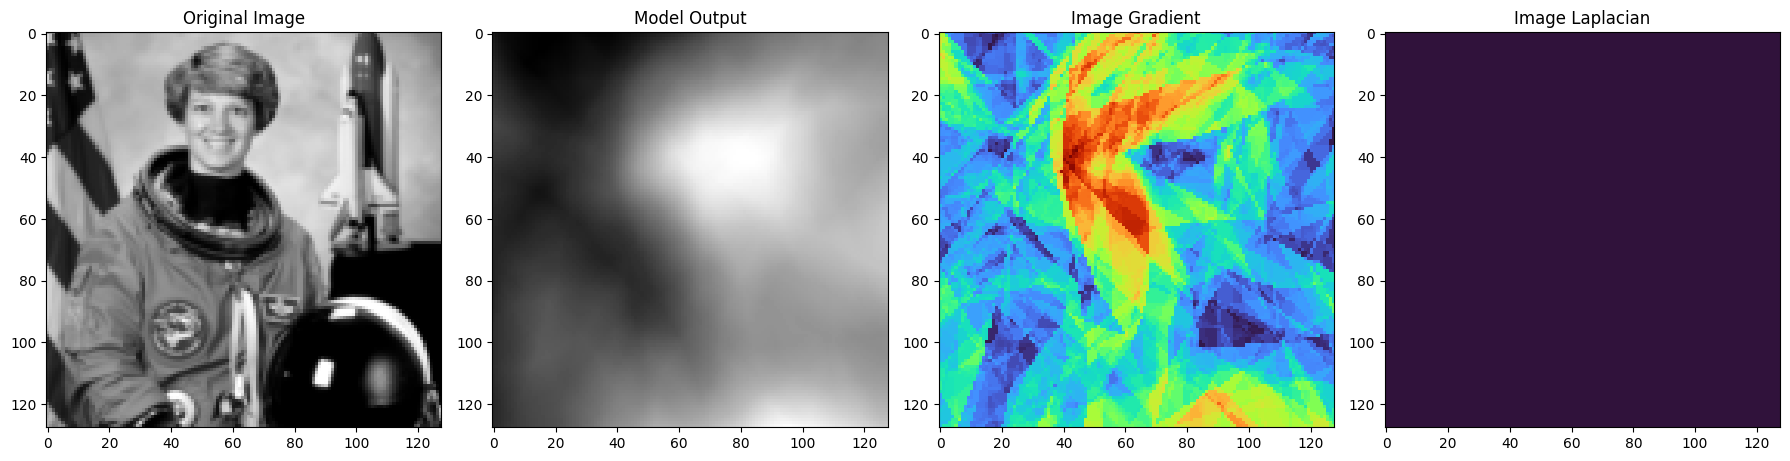

  5%|▍         | 99/2000 [00:11<02:57, 10.73it/s]

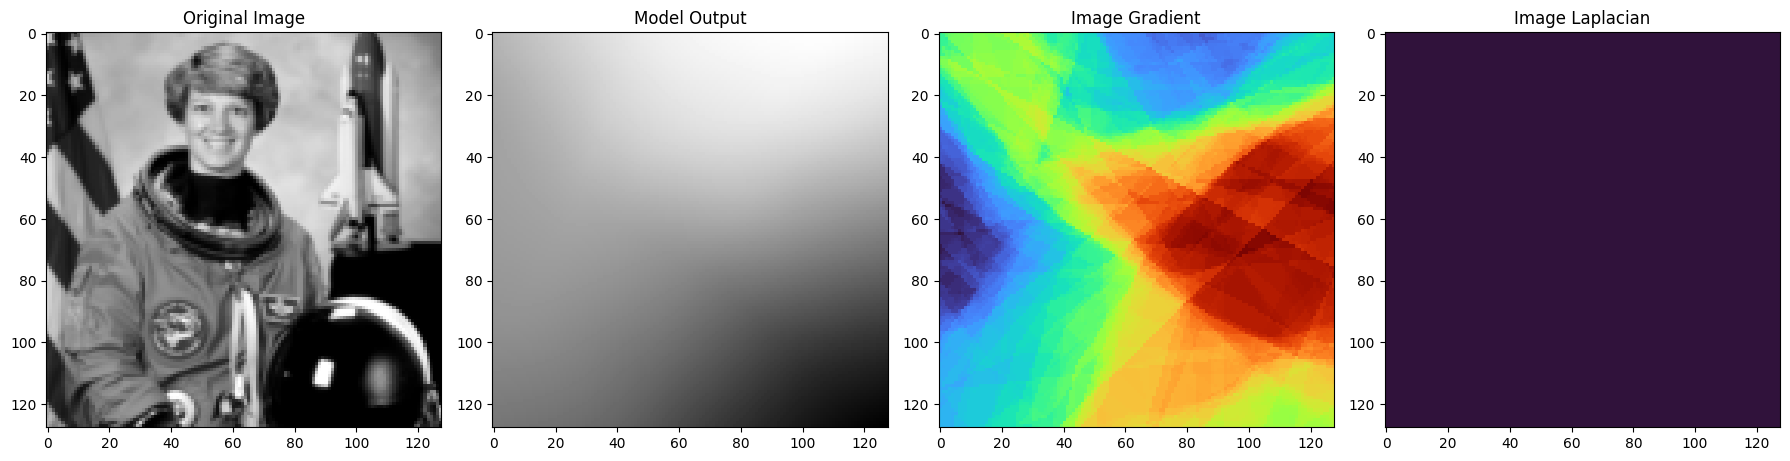

 10%|█         | 200/2000 [00:29<05:33,  5.40it/s]

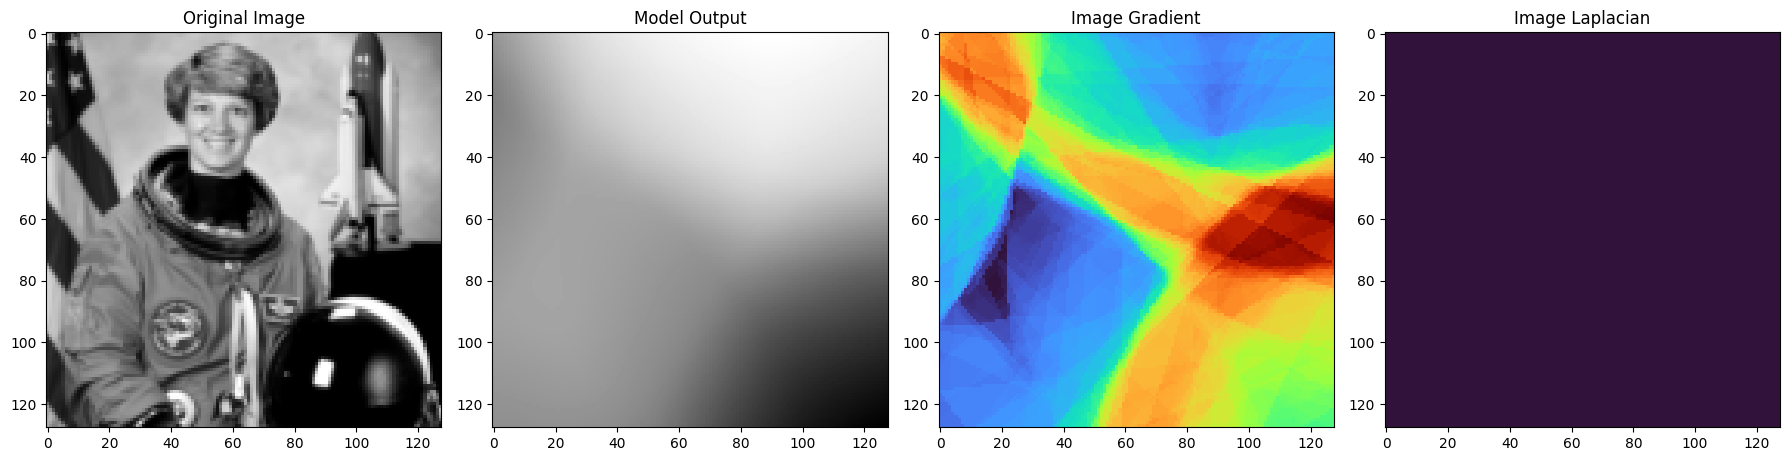

 15%|█▍        | 299/2000 [00:38<01:54, 14.82it/s]

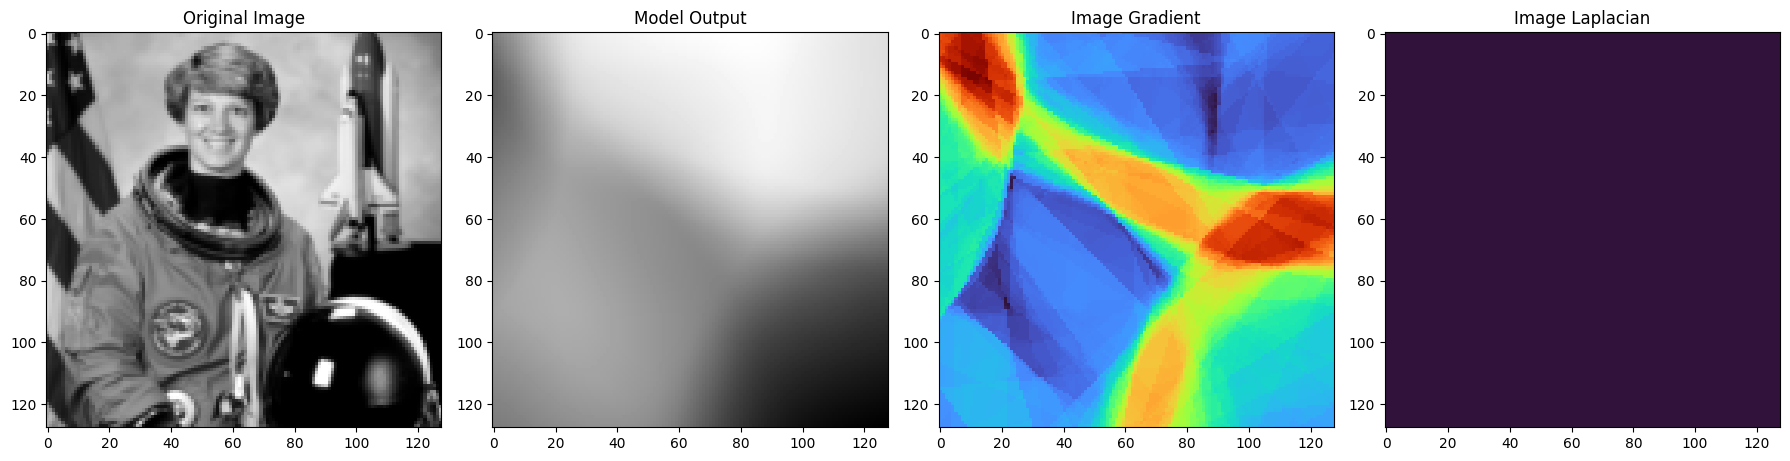

 20%|█▉        | 399/2000 [00:55<02:33, 10.44it/s]

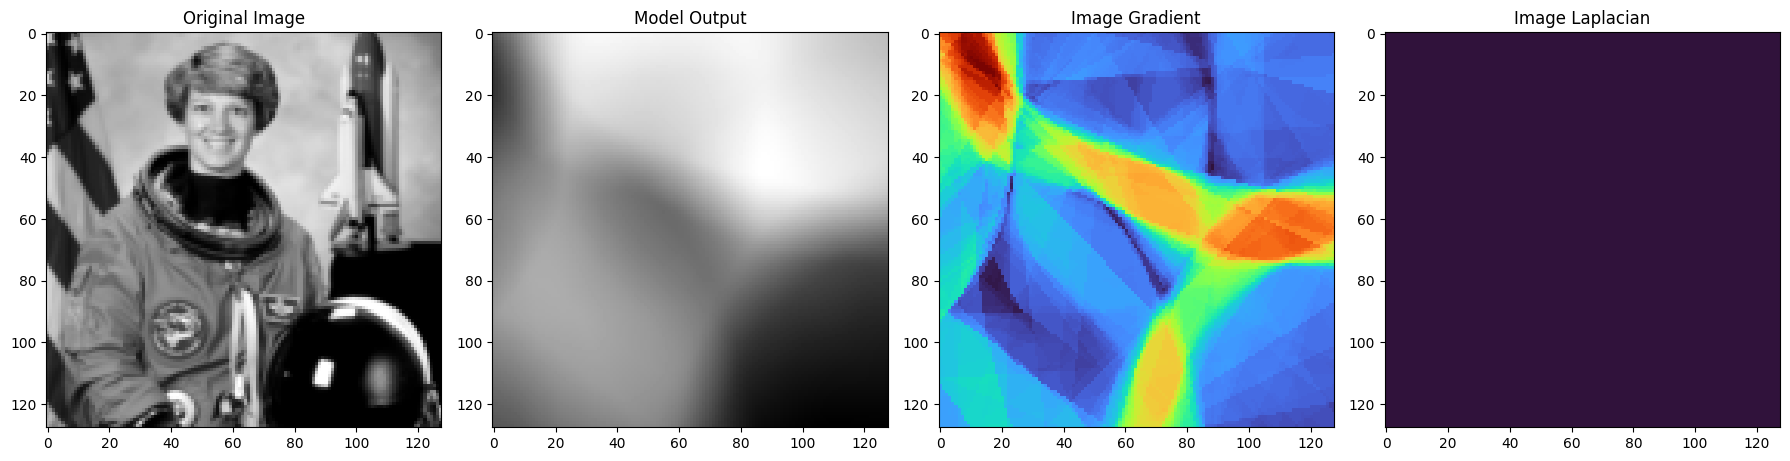

 25%|██▌       | 500/2000 [01:13<02:53,  8.64it/s]

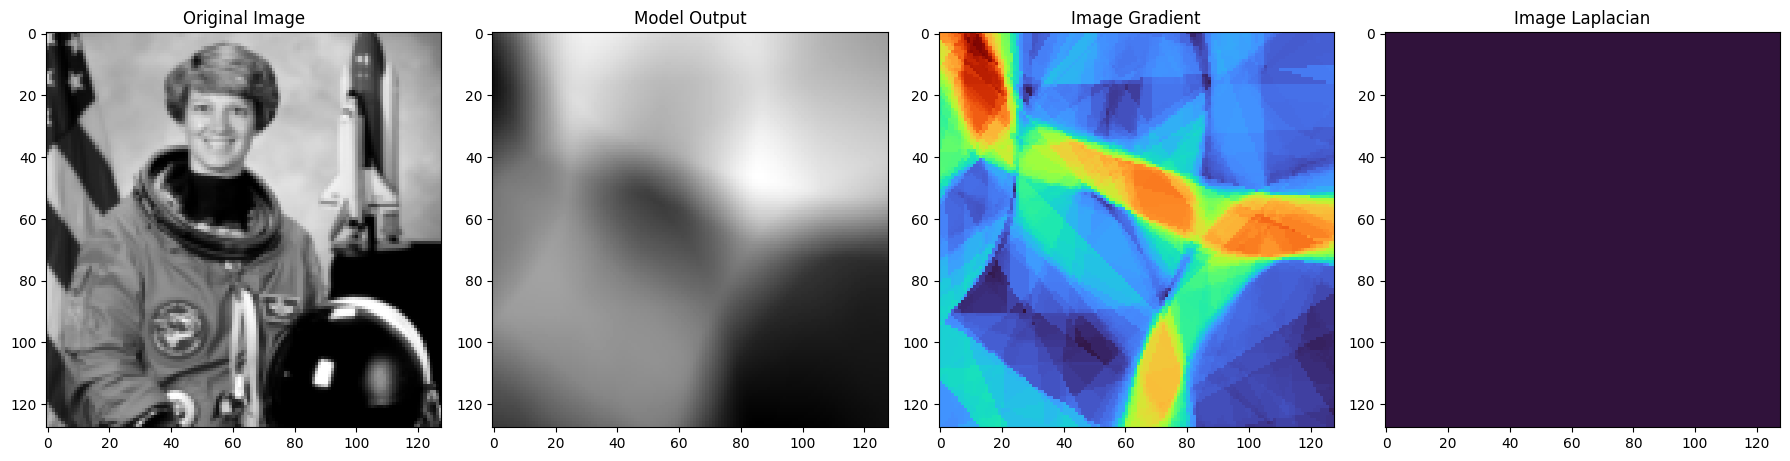

 30%|██▉       | 599/2000 [01:30<01:56, 12.00it/s]

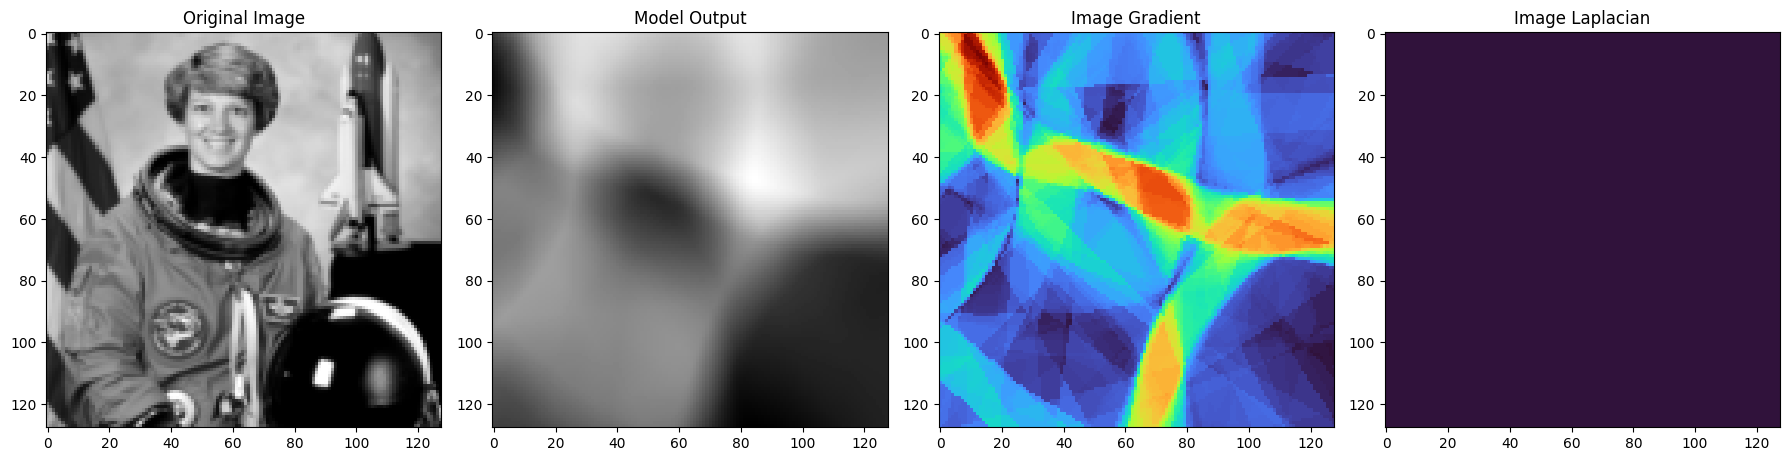

 35%|███▌      | 700/2000 [01:58<10:40,  2.03it/s]

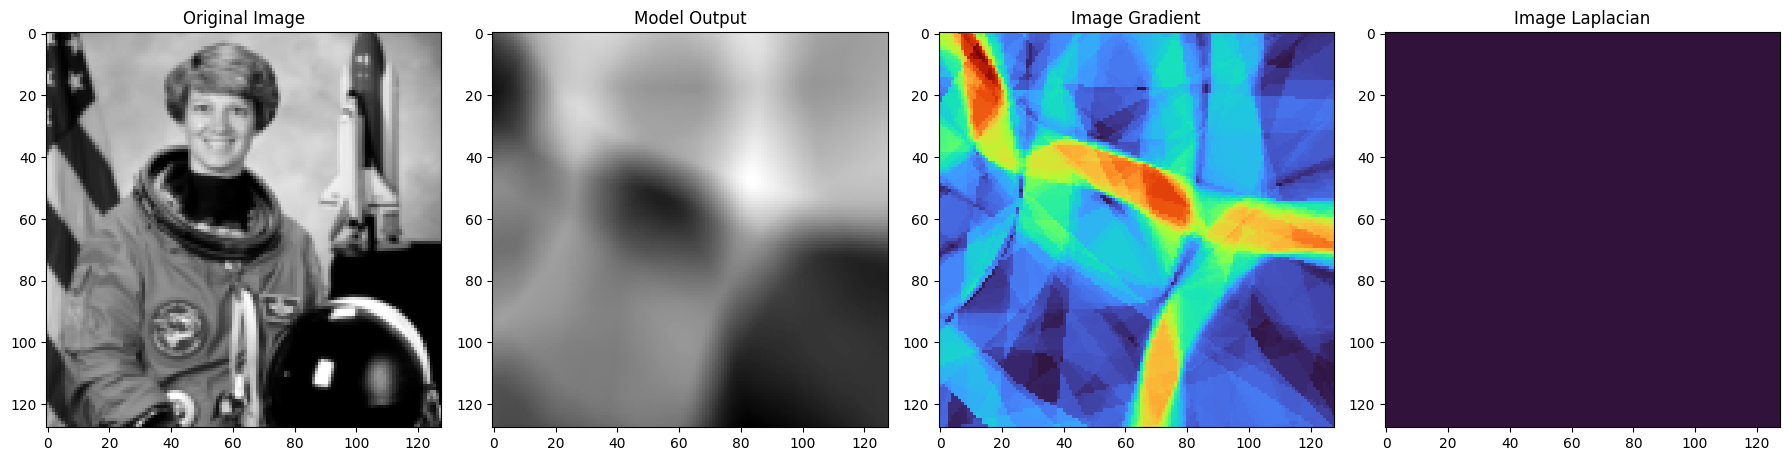

 40%|████      | 800/2000 [02:52<04:17,  4.65it/s]  

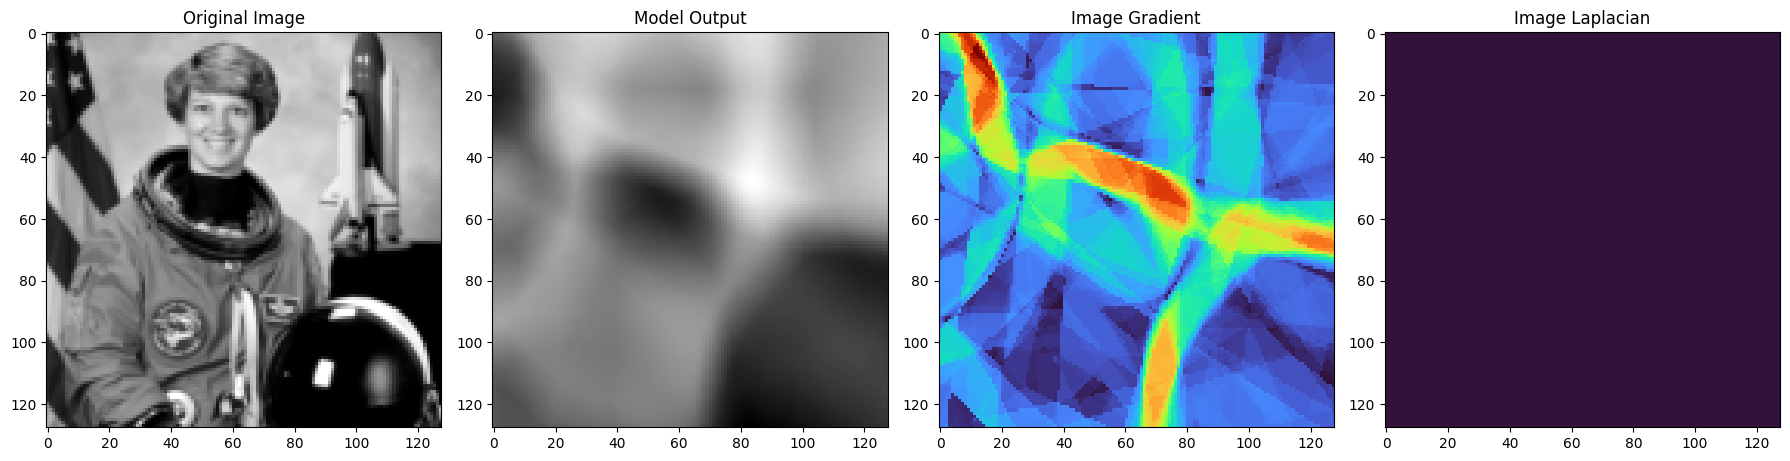

 44%|████▎     | 873/2000 [03:13<06:53,  2.72it/s]

In [ ]:
dataset = ImageDataset(height=128)

mlp_loss, mlp_psnr = train(
    model="MLP",
    dataset=dataset,
    lr=1e-4,
    total_steps=2000,
    steps_til_summary=100,
    device=device,
    **dict(
        in_features=2,
        out_features=1,
        hidden_features=128,
        hidden_layers=3,
        activation="ReLU",
    ),
)

Now fit the SIREN.

In [ ]:
dataset = ImageDataset(height=128)

siren_loss, siren_psnr = train(
    model="SIREN",
    dataset=dataset,
    lr=1e-4,
    total_steps=500,
    steps_til_summary=25,
    device=device,
    **dict(
        in_features=2,
        out_features=1,
        hidden_features=128,
        hidden_layers=3,
    ),
)

Compare the loss and PSNR for the two models.

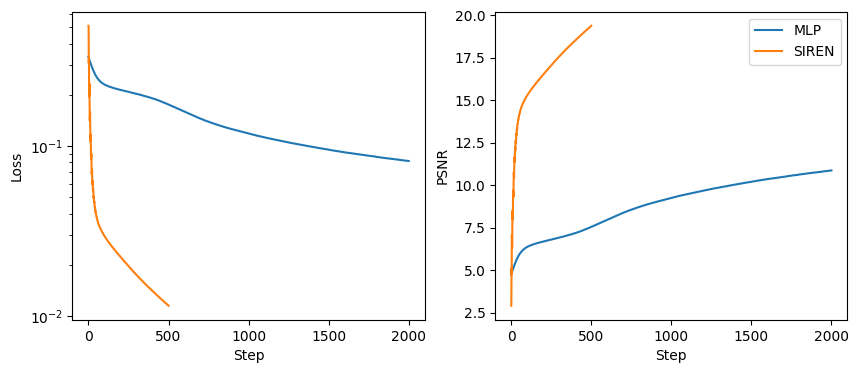

In [6]:
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.plot(mlp_loss, label="MLP")
plt.plot(siren_loss, label="SIREN")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.yscale("log")
plt.subplot(122)
plt.plot(mlp_psnr, label="MLP")
plt.plot(siren_psnr, label="SIREN")
plt.xlabel("Step")
plt.ylabel("PSNR")
plt.legend()
plt.show()